<a href="https://colab.research.google.com/github/SySyAli/Capsule/blob/master/NLP_Project_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created by: Zayaan Rahman and Syed Ali

2/18/2026

NLP Project Part 1

In [ ]:
!pip install datasets pandas tqdm

In [ ]:
from typing import Optional, Union
import logging
import time

from datasets import load_dataset
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import re
from collections import Counter

import matplotlib.pyplot as plt

In [ ]:
AVAILABLE_CATS = [
    "All_Beauty", "Amazon_Fashion", "Appliances", "Arts_Crafts_and_Sewing",
    "Automotive", "Baby_Products", "Beauty_and_Personal_Care", "Books",
    "CDs_and_Vinyl", "Cell_Phones_and_Accessories", "Clothing_Shoes_and_Jewelry",
    "Digital_Music", "Electronics", "Gift_Cards", "Grocery_and_Gourmet_Food",
    "Handmade_Products", "Health_and_Household", "Health_and_Personal_Care",
    "Home_and_Kitchen", "Industrial_and_Scientific", "Kindle_Store",
    "Magazine_Subscriptions", "Movies_and_TV", "Musical_Instruments",
    "Office_Products", "Patio_Lawn_and_Garden", "Pet_Supplies", "Software",
    "Sports_and_Outdoors", "Subscription_Boxes", "Tools_and_Home_Improvement",
    "Toys_and_Games", "Video_Games",
]

DEFAULT_FIELDS = [
    "rating", "title", "text", "asin", "parent_asin",
    "user_id", "timestamp", "helpful_vote", "verified_purchase",
]

In [ ]:
# get review dataset from hugginface
# can choose set of categories and other download options
def load_amazon_reviews(
    cats="Amazon_Fashion", # categories
    max_rev = None, # max number of reviews
    min_length = 3, # min text length
    ratings = None,
    fields = DEFAULT_FIELDS,
) -> pd.DataFrame:

  if isinstance(cats, str):
      cats = [cats]

  for c in cats:
      if c not in AVAILABLE_CATS:
          raise ValueError(f"unknown category '{c}'")

  per_cat = (max_rev // len(cats)) if max_rev else None

  all_frames = []

  for cat in cats:
      print(f"\nloading '{cat}' - target {f'{per_cat:,}' if per_cat else 'all'} reviews")
      dataset = load_dataset(
          "json",
          data_files=f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/{cat}.jsonl",
          split="train",
          streaming=True,
      )

      records, n_seen = [], 0
      with tqdm(total=per_cat, desc=cat) as progress_bar:
          for record in dataset:
              n_seen += 1

              # makes sure text is longer than min length
              if len((record.get("text") or "").strip()) < min_length:
                  continue

              # makes sure rating are valid
              if ratings and record.get("rating") not in [float(r) for r in ratings]:
                  continue

              record_row = {f: record.get(f) for f in fields}
              record_row["category"] = cat
              records.append(record_row)
              progress_bar.update(1)
              if per_cat and len(records) >= per_cat:
                  break

      print(f"  kept {len(records):,} / {n_seen:,} examined")
      all_frames.append(pd.DataFrame(records))

  df = pd.concat(all_frames, ignore_index=True)
  df["timestamp_sec"] = df["timestamp"] / 1000
  df["rating_int"] = df["rating"].astype(int)
  df["helpful_vote"] = df["helpful_vote"].fillna(0).astype(int)

  print(f"\ndone: {df.shape[0]:,} rows × {df.shape[1]} cols")
  print(f"ratings: {df['rating_int'].value_counts().sort_index().to_dict()}")
  return df

In [ ]:
# html first so tags consumed before letter rules match fragments
pattern = re.compile(r"""
    <[^>]+>
    | \$\d+(?:\.\d+)?
    | \d+(?:\.\d+)?
    | [a-z]+(?:['\u2018\u2019][a-z]+)*
    | [a-z]+-[a-z]+
""", re.VERBOSE | re.IGNORECASE)

# generate token list from text
def tokenize(text: str) -> list[str]:
  if not isinstance(text, str) or not text.strip():
      return []

  # filter out html
  return [t.lower() for t in pattern.findall(text) if not t.startswith('<')]

In [ ]:
# compute dla between 2 sections of data
# odds ratio using informative dirichlet prior
def compute_dla(df_a, df_b, text_col='text', min_count=3):
  tokens_a = [token for text in df_a[text_col] for token in tokenize(text)]
  tokens_b = [token for text in df_b[text_col] for token in tokenize(text)]

  count_a, count_b = Counter(tokens_a), Counter(tokens_b)
  n_a, n_b = len(tokens_a), len(tokens_b)
  alpha_0 = n_a + n_b

  results = []

  joint_vocab = set(count_a) | set(count_b)
  # iterate through each unique word in the dataset
  for w in joint_vocab:
      # get the frequency for each word in both corpuses
      f_a, f_b = count_a.get(w, 0), count_b.get(w, 0)
      alpha_w = f_a + f_b  # combined count serves as dirichlet prior

      # filter out extremely rare words
      if alpha_w < min_count:
          continue

      # calculate smoothed log odds for both corpuses
      log_a = np.log((f_a + alpha_w) / (n_a + alpha_0 - f_a - alpha_w))
      log_b = np.log((f_b + alpha_w) / (n_b + alpha_0 - f_b - alpha_w))

      # calculate raw difference and variance
      delta = log_a - log_b
      sigma = np.sqrt((1 / (f_a + alpha_w)) + (1 / (f_b + alpha_w)))

      # calculate the z score
      z = delta / sigma

      results.append({'word': w, 'z_score': z, 'count_a': f_a, 'count_b': f_b})

  return pd.DataFrame(results).sort_values('z_score', ascending=False).reset_index(drop=True)

In [ ]:
# generate window struct from df
def make_window(df, idx):
  dates = pd.to_datetime(df['timestamp'], unit='ms')
  return {
      'window_idx': idx,
      'df': df,
      'start': dates.min().strftime('%Y-%m'),
      'end':   dates.max().strftime('%Y-%m'),
      'n_reviews': len(df),
  }

# print window info
def print_windows(windows):
  for w in windows:
      print(f"  window {w['window_idx']}: {w['start']} → {w['end']}  ({w['n_reviews']:,} reviews)")

# split df by provided ranges
def split_by_date(df, year_ranges, timestamp_col='timestamp'):
  df = df.copy()
  df['_year'] = pd.to_datetime(df[timestamp_col], unit='ms').dt.year
  windows = []

  for i, (y_start, y_end) in enumerate(year_ranges):
      chunk = df[(df['_year'] >= y_start) & (df['_year'] <= y_end)].drop(columns='_year')
      windows.append(make_window(chunk, i + 1))

  print(f"split by date ({len(year_ranges)} windows):")
  print_windows(windows)
  return windows

# split full range into even sections instead
def split_by_year_count(df, n_splits=3, timestamp_col='timestamp'):
  df = df.copy()
  df['_year'] = pd.to_datetime(df[timestamp_col], unit='ms').dt.year
  y_counts = df.groupby('_year').size().sort_index()
  target = y_counts.sum() / n_splits

  buckets, current, current_years = [], 0, []
  for year, count in y_counts.items():
      current_years.append(year)
      current += count

      if current >= target and len(buckets) < n_splits - 1:
          buckets.append(current_years)
          current, current_years = 0, []

  buckets.append(current_years)

  windows = []
  for i, years in enumerate(buckets):
      chunk = df[df['_year'].isin(years)].drop(columns='_year')
      windows.append(make_window(chunk, i + 1))

  print(f"split by year-count balance ({n_splits} windows):")
  print_windows(windows)
  return windows

In [ ]:
# generate graphs of DLA results
def plot_dla(dla_results, label_a, label_b, filename, n=30):
  top_a = dla_results.head(n)
  top_b = dla_results.tail(n).sort_values('z_score')

  fig, axes = plt.subplots(1, 2, figsize=(14, 8))

  axes[0].barh(top_b['word'], top_b['z_score'], color='firebrick')
  axes[0].set_title(f"distinctive to: {label_b}")
  axes[0].set_xlabel("z-score (log-odds)")
  axes[0].invert_xaxis()

  axes[1].barh(top_a['word'], top_a['z_score'], color='seagreen')
  axes[1].set_title(f"distinctive to: {label_a}")
  axes[1].set_xlabel("z-score (log-odds)")

  plt.tight_layout()
  plt.savefig(filename, dpi=150, bbox_inches='tight')
  plt.show()
  print(f"  saved: {filename}")

In [ ]:
# run dla on 1 and 5 star review pairs on given windows
def run_windowed_dla(windows, n=30):
  all_results = {}

  for w in windows:
      label = f"window {w['window_idx']} ({w['start']} -> {w['end']})"

      print(f"\n{'='*55}\n{label}\n{'='*55}")

      df_5 = w['df'][w['df']['rating_int'] == 5]
      df_1 = w['df'][w['df']['rating_int'] == 1]

      print(f"  5-star: {len(df_5):,}  |  1-star: {len(df_1):,}")

      if len(df_5) == 0 or len(df_1) == 0:
          print("  skipping - one group is empty.")
          continue

      results = compute_dla(df_5, df_1)
      all_results[w['window_idx']] = {'results': results, 'meta': w}

      filename = f"dla_window{w['window_idx']}_{w['start']}_{w['end']}.png"
      plot_dla(results, label_a=f"5-star {label}", label_b=f"1-star {label}",
                filename=filename, n=n)

  return all_results

# get unique words in top n between windows
# can show words that represent trends per window
def get_unique_words(all_results, n=100):
  top_5 = {idx: set(r['results'].head(n)['word']) for idx, r in all_results.items()}
  top_1 = {idx: set(r['results'].tail(n)['word']) for idx, r in all_results.items()}

  for idx, r in all_results.items():
      meta = r['meta']
      label = f"window {idx} ({meta['start']} -> {meta['end']})"

      print(f"\n{'='*55}\n{label}\n{'='*55}")

      unique_5 = top_5[idx] - set().union(*[v for k, v in top_5.items() if k != idx])
      unique_1 = top_1[idx] - set().union(*[v for k, v in top_1.items() if k != idx])

      print(f"  unique 5-star words ({len(unique_5)}): {sorted(unique_5)}")
      print(f"  unique 1-star words ({len(unique_1)}): {sorted(unique_1)}")

  stable_5 = set.intersection(*top_5.values())
  stable_1 = set.intersection(*top_1.values())

  print(f"\n{'='*55}\nstable across all windows\n{'='*55}")
  print(f"  always 5-star ({len(stable_5)}): {sorted(stable_5)}")
  print(f"  always 1-star ({len(stable_1)}): {sorted(stable_1)}")


loading 'Amazon_Fashion' — target all reviews


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Amazon_Fashion: 0it [00:00, ?it/s]

  kept 2,492,799 / 2,500,939 examined

done: 2,492,799 rows × 12 cols
ratings: {1: 302814, 2: 173191, 3: 244590, 4: 351153, 5: 1421051}
rating_int      1      2      3      4       5
year                                          
2002            0      0      0      1       5
2003            0      0      1      3       6
2004            3      3      6      6      17
2005           11      3     10     13      32
2006           12     12     20     27      83
2007           53     57     82    172     504
2008           69     60     96    205     749
2009           88     61    136    246     885
2010          123    122    172    356    1096
2011          252    165    285    614    1688
2012          556    420    662   1297    4460
2013         1742   1391   2371   4216   13231
2014         5058   3645   6164  10407   34190
2015        11188   7798  12672  21462   74621
2016        26740  18372  29315  50018  163277
2017        38648  26779  39710  60975  204641
2018        43186 

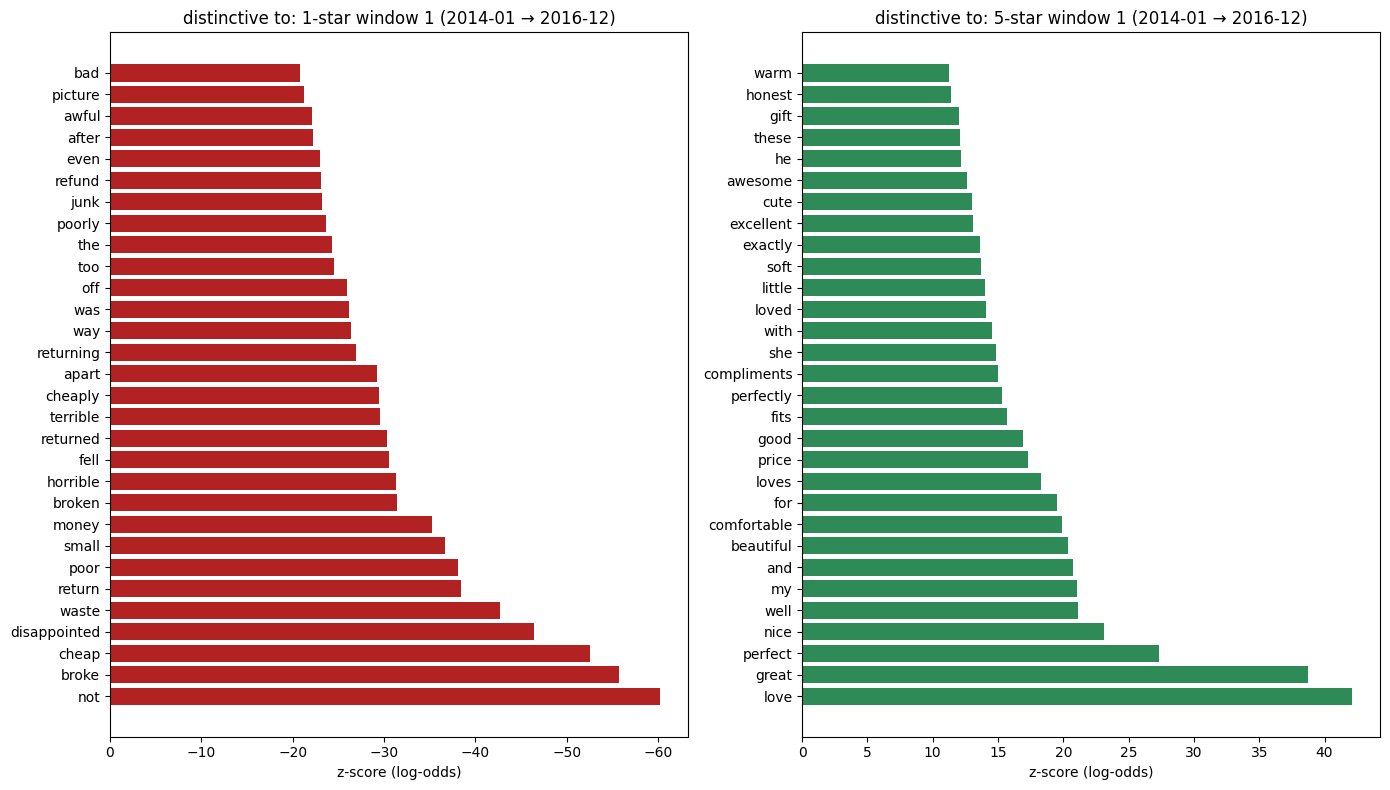

  saved: dla_window1_2014-01_2016-12.png

window 2 (2017-01 → 2019-12)
  5-star: 657,448  |  1-star: 133,457


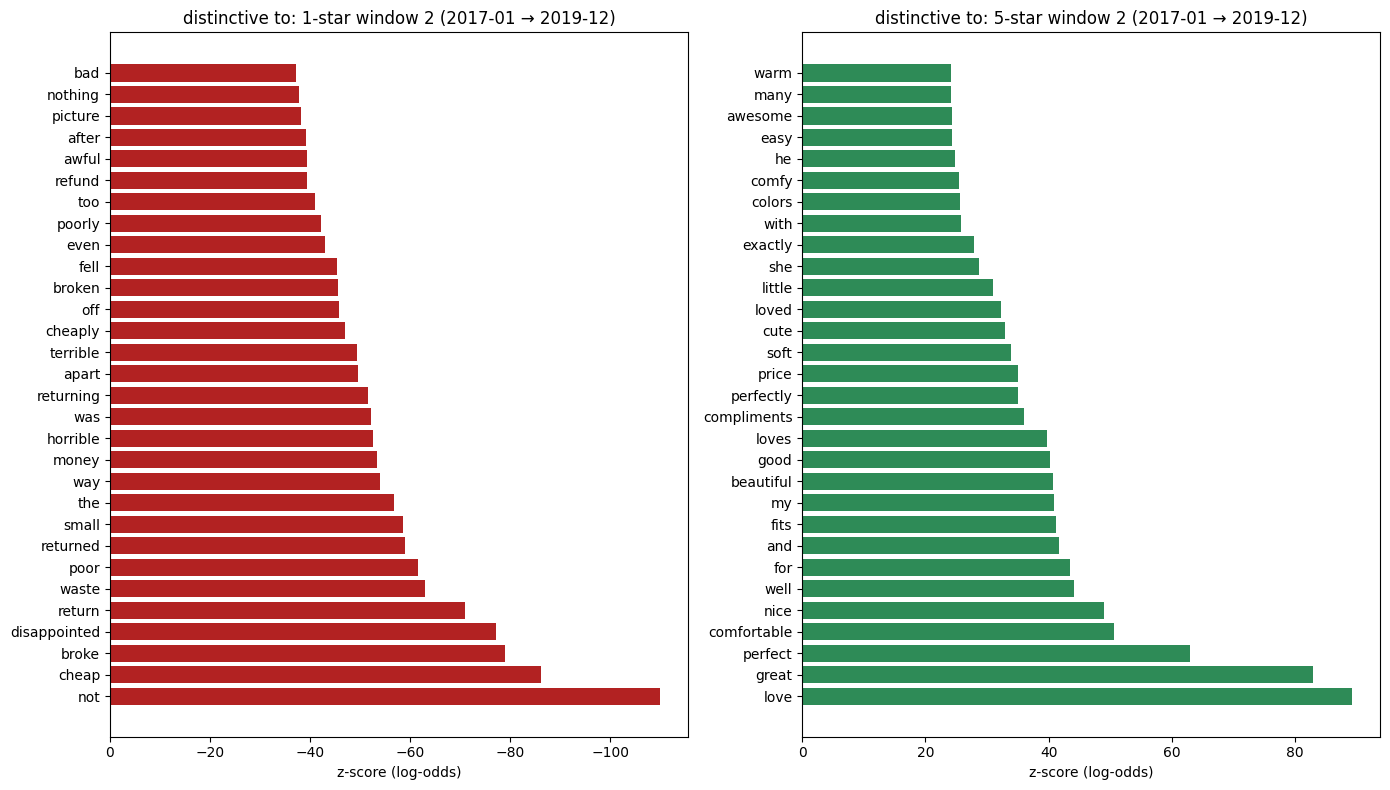

  saved: dla_window2_2017-01_2019-12.png

window 3 (2020-01 → 2022-12)
  5-star: 448,184  |  1-star: 118,481


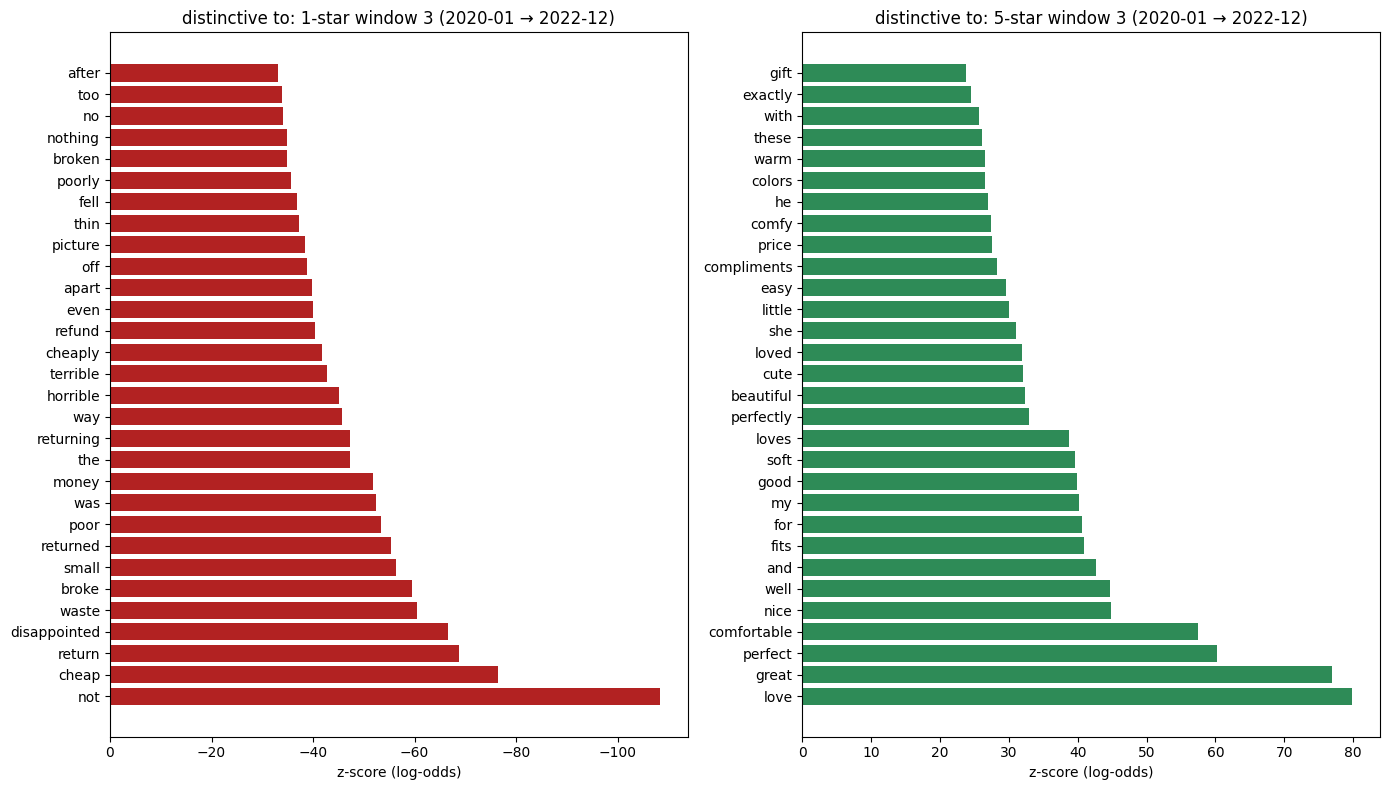

  saved: dla_window3_2020-01_2022-12.png
split by date (1 windows):
  window 1: 2002-05 → 2023-09  (2,492,799 reviews)

window 1 (2002-05 → 2023-09)
  5-star: 1,421,051  |  1-star: 302,814


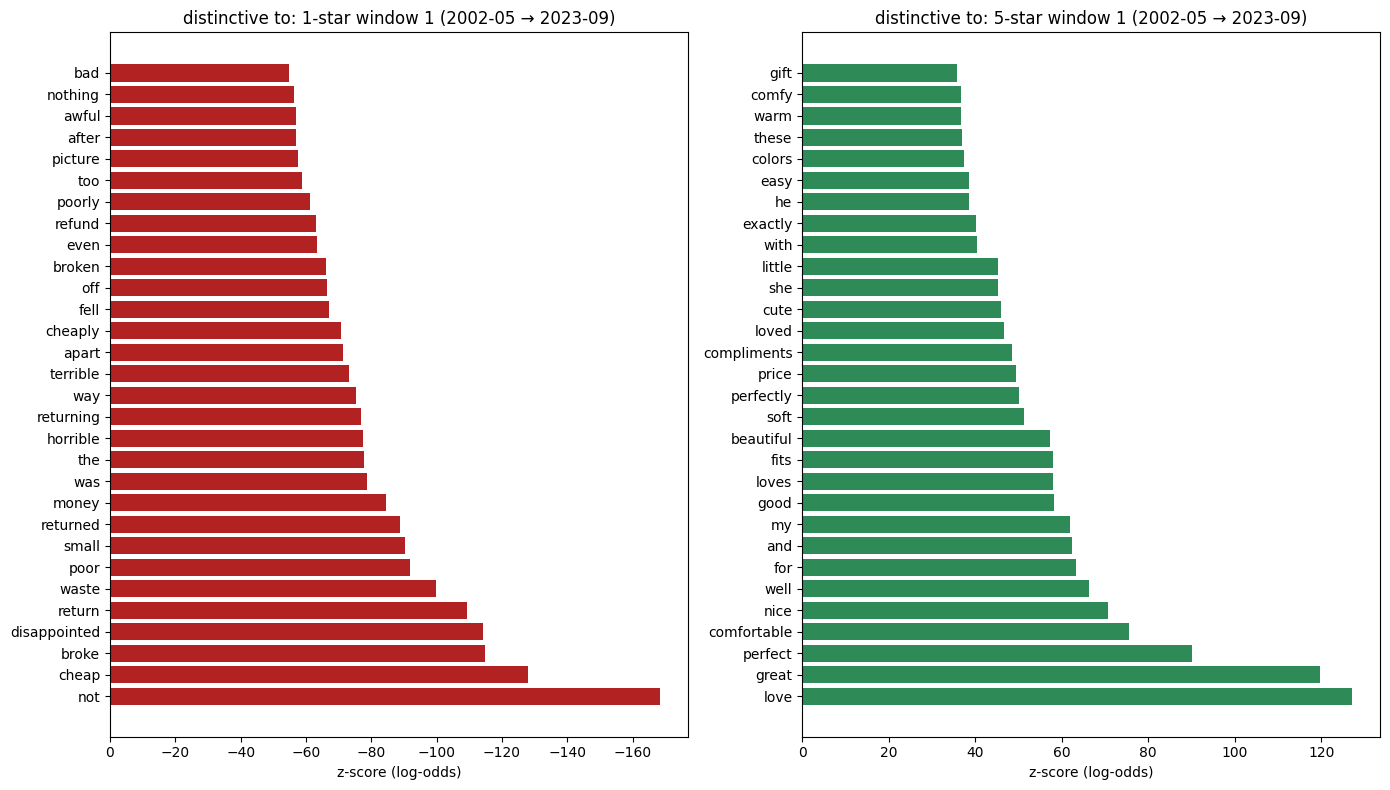

  saved: dla_window1_2002-05_2023-09.png

window 1 (2014-01 → 2016-12)
  unique 5-star words (12): ['a', 'carry', 'discount', 'discounted', 'exchange', 'fantastic', 'has', 'honest', 'review', 'this', 'unbiased', 'wallet']
  unique 1-star words (17): ['bent', 'child', 'clasp', "don't", 'fake', 'guess', 'impossible', 'minutes', 'misleading', 'ridiculous', 'tiny', 'total', 'unhappy', 'upset', 'wasted', "wouldn't", 'xl']

window 2 (2017-01 → 2019-12)
  unique 5-star words (2): ['expected', "i'm"]
  unique 1-star words (6): ['already', 'came', 'close', 'sewn', 'stuck', 'zipper']

window 3 (2020-01 → 2022-12)
  unique 5-star words (11): ['adjustable', 'breathable', 'comfort', 'enough', 'everyday', 'granddaughter', 'him', 'length', 'likes', 'surprised', 'winter']
  unique 1-star words (10): ['advertised', 'all', 'false', 'material', 'only', 'photo', 'polyester', 'see', 'seller', 'supposed']

stable across all windows
  always 5-star (77): ['absolutely', 'adorable', 'always', 'amazing', 'and',

In [ ]:
amazon_df = load_amazon_reviews(cats="Amazon_Fashion")

# review counts by year and rating, for context
amazon_df['year'] = pd.to_datetime(amazon_df['timestamp'], unit='ms').dt.year
print(amazon_df.groupby(['year', 'rating_int']).size().unstack(fill_value=0).to_string())

# analysis on 3 even periods with enough data
windows = split_by_date(amazon_df, [(2014, 2016), (2017, 2019), (2020, 2022)])
results_windowed = run_windowed_dla(windows, n=30)

# full dataset as single window for baseline
windows_full = split_by_date(amazon_df, [(2002, 2023)])
results_full = run_windowed_dla(windows_full, n=30)

# unique and stable words across the three windows
get_unique_words(results_windowed, n=100)

In [ ]:
# count vocab size
all_tokens = [tokenize(t) for t in amazon_df["text"]]
vocab = set(t for tokens in all_tokens for t in tokens)

print(f"vocab size: {len(vocab):,}")
print(f"total tokens: {sum(len(t) for t in all_tokens):,}")

vocab size: 157,338
total tokens: 67,991,970


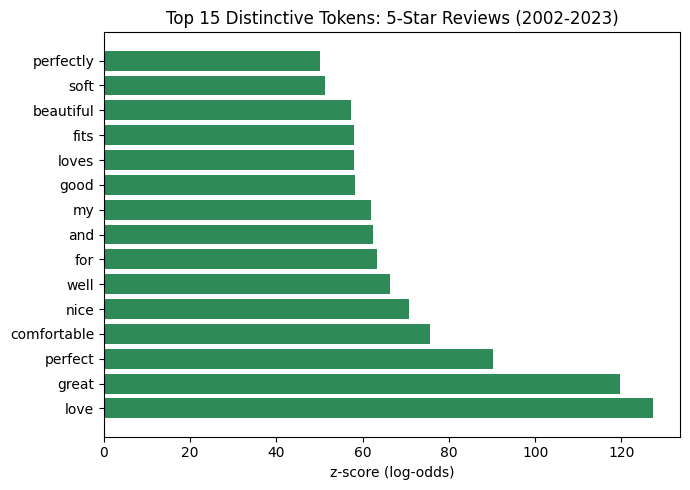

  saved: dla_full_5star.png


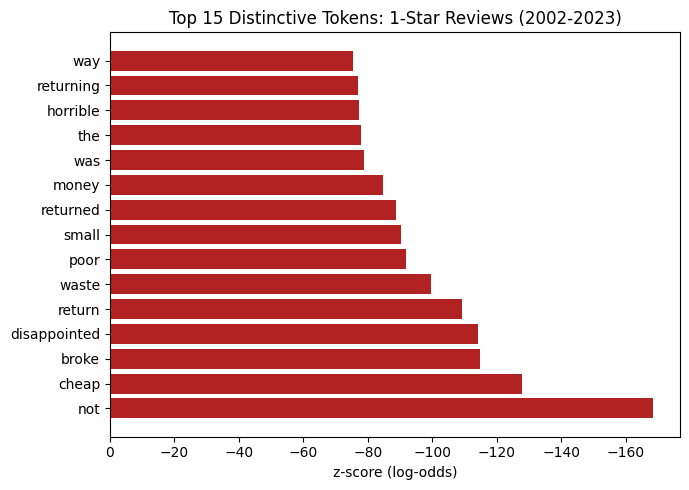

  saved: dla_full_1star.png


In [ ]:
def plot_dla_split(dla_results, label_a, label_b, filename_a, filename_b, n=10):
    top_a_results = dla_results.head(n)
    top_b_results = dla_results.tail(n).sort_values('z_score')

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.barh(top_a_results['word'], top_a_results['z_score'], color='seagreen')
    ax.set_title(f"Top {n} Distinctive Tokens: {label_a}")
    ax.set_xlabel("z-score (log-odds)")

    plt.tight_layout()
    plt.savefig(filename_a, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  saved: {filename_a}")

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.barh(top_b_results['word'], top_b_results['z_score'], color='firebrick')
    ax.set_title(f"Top {n} Distinctive Tokens: {label_b}")
    ax.set_xlabel("z-score (log-odds)")

    ax.invert_xaxis()
    plt.tight_layout()
    plt.savefig(filename_b, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  saved: {filename_b}")

# run on stored results for paper
plot_dla_split(
    results_full[1]['results'],
    label_a="5-Star Reviews (2002-2023)",
    label_b="1-Star Reviews (2002-2023)",
    filename_a="dla_full_5star.png",
    filename_b="dla_full_1star.png",
    n=15
)